# Challenge Kaggle — Crab Age Regression

**Objectif :** Prédire l'âge d'un crabe à partir de ses caractéristiques physiques.

**Métrique d'évaluation :** MAE (Mean Absolute Error)

---

Ce notebook est une **baseline** : un point de départ simple et fonctionnel.  
Votre mission : faire mieux que cette baseline !

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

## 1. Chargement des données

In [2]:
TRAIN_PATH = '/kaggle/input/competitions/efrei-2026-crab-regression-challenge/train.csv'
TEST_PATH  = '/kaggle/input/competitions/efrei-2026-crab-regression-challenge/test.csv'

# On définit 'id' comme index dès le départ
train_df = pd.read_csv(TRAIN_PATH, index_col='id')
test_df = pd.read_csv(TEST_PATH, index_col='id')

print(f"Train : {train_df.shape}")
print(f"Test  : {test_df.shape}")
train_df.head()

Train : (15000, 9)
Test  : (10000, 8)


,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
id,,,,,,,,,
0,M,1.4875,1.1000,0.4250,37.152020,17.335719,8.462326,8.930093,9.0
1,M,1.5250,1.1750,0.4250,29.157461,12.062712,6.988152,8.930093,9.0
2,I,1.3375,1.0000,0.3000,16.428535,7.030676,3.898056,4.961163,8.0
3,I,0.7500,0.5500,0.1625,3.671260,1.474174,0.949708,0.992232,5.0
4,M,1.4750,1.1875,0.3875,31.326197,13.324265,6.761356,7.796112,10.0


In [3]:
train_df.describe()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.314114,1.021969,0.346207,23.207945,10.029359,5.011420,6.648089,9.922467
std,0.289515,0.238842,0.090708,12.618130,5.600515,2.794041,3.566568,3.196259
min,0.275000,0.125000,0.000000,0.141747,0.070874,0.085048,0.085048,1.000000
25%,1.150000,0.875000,0.287500,13.168343,5.669900,2.778251,3.827183,8.000000
50%,1.375000,1.075000,0.362500,23.700182,9.893975,4.918638,6.803880,10.000000
75%,1.525000,1.200000,0.412500,32.134158,13.947954,6.959802,9.071840,11.000000
max,2.037500,1.950000,0.625000,78.797435,38.229301,18.228728,32.119983,29.000000


## 2. Exploration

In [4]:
# Valeurs manquantes
print("=== Valeurs manquantes ===")
print(train_df.isnull().sum())

=== Valeurs manquantes ===
Sex               0
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
Age               0
dtype: int64


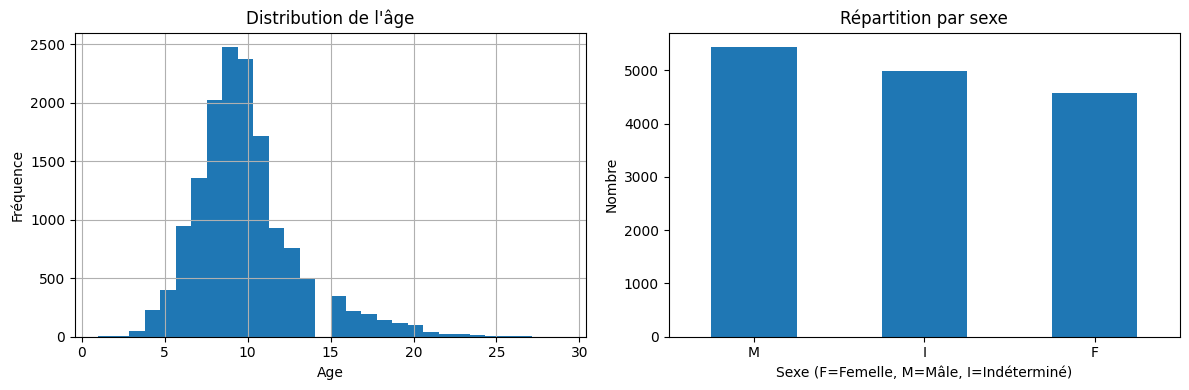

In [5]:
# Distribution de la cible + répartition par sexe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['Age'].hist(bins=30, ax=axes[0])
axes[0].set_title("Distribution de l'âge")
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fréquence')

train_df['Sex'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Répartition par sexe')
axes[1].set_xlabel('Sexe (F=Femelle, M=Mâle, I=Indéterminé)')
axes[1].set_ylabel('Nombre')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [6]:
# Corrélations avec la cible
corr = train_df.select_dtypes('number').corr()['Age'].drop('Age').sort_values(ascending=False)
print("=== Corrélations avec Age ===")
print(corr.round(3))

=== Corrélations avec Age ===
Shell Weight      0.683
Height            0.665
Diameter          0.634
Length            0.628
Weight            0.614
Viscera Weight    0.584
Shucked Weight    0.509
Name: Age, dtype: float64


## 3. Preprocessing

In [7]:
# X contient tout sauf la cible. Plus besoin de dropper 'id', il est en index.
X = train_df.drop('Age', axis=1)
y = train_df['Age']

# Encodage de la variable catégorielle 'Sex'
X = pd.get_dummies(X, columns=['Sex'])
X_test_final = pd.get_dummies(test_df, columns=['Sex'])

print("Features :", list(X.columns))

Features : ['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight', 'Sex_F', 'Sex_I', 'Sex_M']


## 4. Split entraînement / validation

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} exemples")
print(f"Val   : {X_val.shape[0]} exemples")

Train : 12000 exemples
Val   : 3000 exemples


## 5. Modèle — Baseline

On commence avec un arbre de décision simple.

In [9]:
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

## 6. Évaluation locale

In [10]:
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE Locale : {mae:.4f}")

MAE Locale : 1.4534


## 7. Génération de la soumission

In [11]:
SUBMISSION_PATH = '/kaggle/working/submission.csv'

# On prédit sur le test set
predictions = model.predict(X_test_final)

# DataFrame de soumission en utilisant l'index du test_df
submission = pd.DataFrame({'Age': predictions}, index=test_df.index)

# Export CSV (on garde l'index !)
submission.to_csv(SUBMISSION_PATH)
print("Fichier prêt !")
submission.head()

Fichier prêt !


,Age
id,
15000,14.481818
15001,7.768566
15002,12.203240
15003,9.780347
15004,7.145038


---

## À vous de jouer !

Pistes pour améliorer la baseline :

- **Feature engineering** : créer de nouvelles features (ratios, interactions)
- **Modèles plus puissants** : Random Forest, Gradient Boosting (XGBoost, LightGBM)
- **Hyperparameter tuning** : `GridSearchCV`, `RandomizedSearchCV`
- **Validation croisée** : `cross_val_score` pour une estimation plus fiable
- **Stacking / Ensembling** : combiner plusieurs modèles